# How OpenSidewalks NYC is pieced together

[Brownsville demo](https://msradam.github.io/opensidewalks-nyc/) · [Repository](https://github.com/msradam/opensidewalks-nyc) · [Download](https://github.com/msradam/opensidewalks-nyc/releases/latest)

This notebook follows a few blocks of Washington Heights in Manhattan from the public sources to the published graph. Each step shows a raw source, the pipeline function that turns it into OpenSidewalks Nodes and Edges, and what that step left in the published release.

It reads the published release over the network, a few blocks at a time, so it does not need the full build (about 48 minutes and 35 GB of memory). It calls the same functions as `python -m pipeline build`, imported from this repository.

Read the [Disclaimer](#Disclaimer) at the end before using the data. The evidence behind its numbers, and what that evidence does not show, is in [`evaluation/`](https://github.com/msradam/opensidewalks-nyc/tree/main/evaluation). Questions and corrections go to the project's [GitHub issues](https://github.com/msradam/opensidewalks-nyc/issues).

Map data in every figure: © [OpenStreetMap contributors](https://www.openstreetmap.org/copyright) (ODbL), NYC DOT, NYC OTI, NY State GIS and NOAA.

To run it yourself:

```bash
git clone https://github.com/msradam/opensidewalks-nyc && cd opensidewalks-nyc
uv venv --python 3.11 && source .venv/bin/activate
uv pip install -e ".[notebook]"
jupyter lab notebooks/how-it-works.ipynb
```

In [1]:
import importlib.util, io, json, sys, tempfile, time, warnings
from urllib.parse import quote
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import rasterio
import requests

REPO = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
warnings.filterwarnings("ignore", category=UserWarning)

from pipeline.stages.schema_map import _classify_osm_edge, _ramps_to_curb_nodes, _join_widths_from_planimetric
from pipeline.stages.assemble import _endpoint_coords, _snap_curb_nodes
from pipeline.stages.acquire import _fetch_dem_tile

def load_module(path):
    spec = importlib.util.spec_from_file_location(Path(path).stem.replace("-", "_"), REPO / path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

osw_to_unweaver = load_module("scripts/osw_to_unweaver.py")
cost_wheelchair = load_module("unweaver-project/cost-wheelchair.py")

RELEASE = "/vsicurl/https://github.com/msradam/opensidewalks-nyc/releases/download/v0.3.4-nyc.1/nyc-osw.fgb"
UTM = "EPSG:32618"   # metres, for distances and lengths
AREA = dict(west=-73.9425, south=40.8490, east=-73.9360, north=40.8530)   # around W 181st St
BBOX = (AREA["west"], AREA["south"], AREA["east"], AREA["north"])
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 11, "figure.facecolor": "white"})

def read_open_data(url, tries=4):
    # NYC Open Data sometimes answers with a server error; try again before giving up.
    for attempt in range(tries):
        r = requests.get(url, timeout=60)
        if r.ok:
            return gpd.read_file(io.BytesIO(r.content))
        time.sleep(2 ** attempt)
    r.raise_for_status()

def credit(fig):
    fig.subplots_adjust(bottom=0.15)
    fig.text(0.01, 0.01, "Map data © OpenStreetMap contributors (openstreetmap.org/copyright), ODbL. NYC DOT, NYC OTI, NY State GIS, NOAA", fontsize=7, color="#555555")

## The published graph

The OpenSidewalks Schema describes a pedestrian network as Nodes (points with an `_id`) and Edges (lines whose `_u_id` and `_v_id` name the Nodes they start and end at). A graph can be built from those fields alone, with no spatial matching. FlatGeobuf supports reading one bounding box over HTTP, so this cell downloads only the features around W 181st Street.

In [2]:
g = gpd.read_file(RELEASE, bbox=BBOX)
edges = g[g.geom_type == "LineString"].copy()
nodes = g[g.geom_type == "Point"].copy()

def entity(row):
    if row["highway"] == "steps":
        return "Steps"
    if row["highway"] == "pedestrian":
        return "Pedestrian Road"
    if row["highway"] == "footway":
        return {"sidewalk": "Sidewalk", "crossing": "Crossing"}.get(row["footway"], "Footway")
    return "Street"

edges["entity"] = edges.apply(entity, axis=1)
nodes["entity"] = np.where(nodes["barrier"] == "kerb", "Curb Ramp", "Node")
pd.concat([edges["entity"], nodes["entity"]]).value_counts().rename("features in this area").rename_axis(None).to_frame()

,features in this area
Node,663
Sidewalk,582
Footway,502
Street,480
Crossing,196
Curb Ramp,101
Pedestrian Road,48
Steps,8


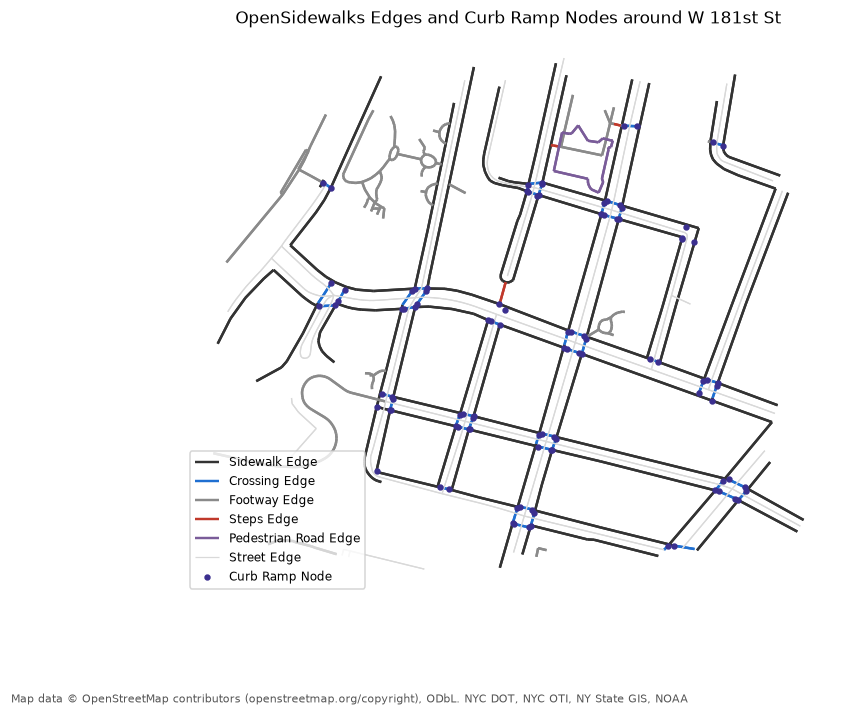

In [3]:
COLOURS = {"Sidewalk": "#333333", "Crossing": "#1f6fd1", "Footway": "#8a8a8a", "Steps": "#c0392b", "Pedestrian Road": "#7a5c99", "Street": "#d9d9d9"}

def base_map(ax, title):
    for name, colour in COLOURS.items():
        part = edges[edges["entity"] == name].to_crs(UTM)
        part.plot(ax=ax, color=colour, linewidth=0.8 if name == "Street" else 1.6, label=f"{name} Edge")
    ax.set_title(title); ax.set_axis_off()

fig, ax = plt.subplots(figsize=(9, 7)); credit(fig)
base_map(ax, "OpenSidewalks Edges and Curb Ramp Nodes around W 181st St")
nodes[nodes["entity"] == "Curb Ramp"].to_crs(UTM).plot(ax=ax, color="#3b2f8f", markersize=10, zorder=3, label="Curb Ramp Node")
ax.legend(loc="lower left", fontsize=8);

## Step 1: OpenStreetMap ways become Edges

The pipeline reads one dated OpenStreetMap extract (Geofabrik, 1 October 2026), keeps the ways a pedestrian can use, and gives each one an OpenSidewalks entity type from its tags. This is the function that decides, applied to a few typical tag sets. `None` means the way is left out.

In [4]:
examples = pd.DataFrame([
    {"highway": "footway", "footway": "sidewalk"},
    {"highway": "footway", "footway": "crossing"},
    {"highway": "footway", "crossing": "marked"},
    {"highway": "steps"},
    {"highway": "path"},
    {"highway": "pedestrian"},
    {"highway": "cycleway", "foot": "designated"},
    {"highway": "cycleway"},
    {"highway": "residential"},
])
examples["pipeline class"] = [_classify_osm_edge(row) for _, row in examples.iterrows()]
examples.fillna("")

,highway,footway,crossing,foot,pipeline class
0,footway,sidewalk,,,sidewalk
1,footway,crossing,,,crossing
2,footway,,marked,,crossing
3,steps,,,,footway
4,path,,,,footway
5,pedestrian,,,,footway
6,cycleway,,,designated,footway
7,cycleway,,,,
8,residential,,,,street


Steps and Pedestrian Roads are their own Edge types in the OpenSidewalks Schema, identified by `highway=steps` and `highway=pedestrian`. The classifier above files them with footways for the pipeline's own bookkeeping. The published Edges keep their `highway` value, so in the release they are Steps and Pedestrian Road Edges and a routing profile can tell them apart.

OpenSidewalks Edges are directional, because `incline` only has a meaning in a direction of travel. This dataset stores both directions of every segment, so each OSM way appears as pairs of Edges with opposite signs of incline.

In [5]:
steep = edges[(edges["entity"] == "Sidewalk") & (edges["incline"] > 0.03)].iloc[0]
way = edges[((edges["_u_id"] == steep["_u_id"]) & (edges["_v_id"] == steep["_v_id"])) |
            ((edges["_u_id"] == steep["_v_id"]) & (edges["_v_id"] == steep["_u_id"]))]
way[["_id", "_u_id", "_v_id", "ext:osm_id", "name", "incline"]]

,_id,_u_id,_v_id,ext:osm_id,name,incline
4,422d59e1f7aa50a4,bbce1a6f90965c6d,706e885109d0b6d4,1038397299,NaN,-0.0559
5,1baa9c92bd22d964,706e885109d0b6d4,bbce1a6f90965c6d,1038397299,NaN,0.0559


## Step 2: Surveyed curb ramps become Curb Ramp Nodes

NYC DOT publishes 217,679 surveyed curb ramps on NYC Open Data (dataset `ufzp-rrqu`). Cyclomedia collected the survey for DOT from vehicle-mounted street-level imagery and LiDAR, mostly in 2018. Nobody measured the ramps on site for this dataset. The pipeline turns each survey record into a Curb Ramp Node, keeping the survey's slopes and warning surface status, and then moves it onto the nearest Edge endpoint within 5 m.

The schema puts a curb where a Crossing meets the short Footway that leads to the Sidewalk. NYC's OpenStreetMap data mostly joins Crossings straight to Sidewalks, and this dataset keeps that layout, so many ramps sit on that junction or on a Sidewalk vertex.

The survey records that a ramp was there, not that it is usable today.

In [6]:
url = ("https://data.cityofnewyork.us/resource/ufzp-rrqu.geojson?$limit=5000&$where="
       f"within_box(the_geom,{AREA['north']},{AREA['west']},{AREA['south']},{AREA['east']})")
ramps_raw = read_open_data(url)
print(len(ramps_raw), "survey records in this area")
ramps_raw[["rampid", "stname1", "stname2", "ramp_running_slope_total", "ramp_cross_slope", "dws_conditions"]].head()

101 survey records in this area


,rampid,stname1,stname2,ramp_running_slope_total,ramp_cross_slope,dws_conditions
0,200680,WEST 180 STREET,FT WASHINGTON AVENUE,3.1,-1.6,Missing
1,200690,WEST 180 STREET,FT WASHINGTON AVENUE,2.9,-1.1,Missing
2,204377,PINEHURST AVENUE,WEST 180 STREET,7.3,-3.2,Missing
3,202920,WEST 180 STREET,PINEHURST AVENUE,5.6,-2.6,Missing
4,200699,WEST 180 STREET,FT WASHINGTON AVENUE,3.1,-0.9,Missing


In [7]:
curbs = _ramps_to_curb_nodes(ramps_raw, "0.3.4+nyc.1", manifest={})
walk_edges = edges[edges["entity"].isin(["Sidewalk", "Crossing", "Footway", "Pedestrian Road", "Steps"])]
snapped = _snap_curb_nodes(curbs, _endpoint_coords(walk_edges), snap_tolerance_m=5.0)
curbs[["_id", "kerb", "tactile_paving", "ext:running_slope_pct", "ext:cross_slope_pct"]].head()

    DOT ramps → CurbRamp nodes: 101


    Building KD-tree over 2,672 edge endpoints...


    Snapped 98/101 curb nodes (tolerance 5.0 m)


,_id,kerb,tactile_paving,ext:running_slope_pct,ext:cross_slope_pct
0,7ec968c70efc78df,lowered,no,3.1,-1.6
1,910f8933ea0bc9fd,lowered,no,2.9,-1.1
2,435cf85bdf417af2,lowered,no,7.3,-3.2
3,c7284117e2e95c11,lowered,no,5.6,-2.6
4,10ff9d8bd0ae1e85,lowered,no,3.1,-0.9


98 of 101 ramps snapped, median move 1.1 m


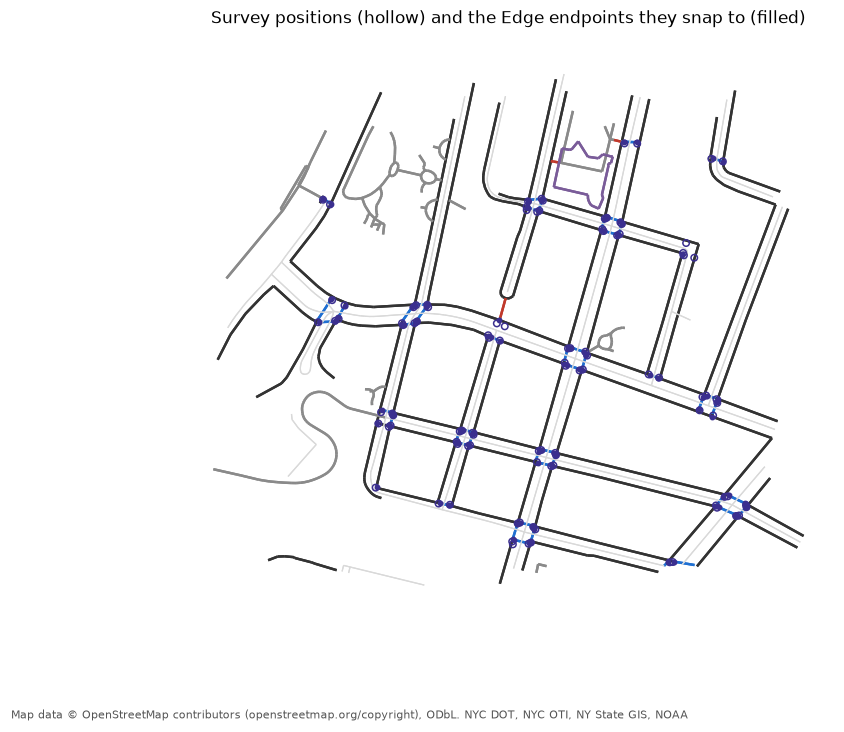

In [8]:
moved = gpd.GeoDataFrame({"before": curbs.geometry.values, "after": snapped.geometry.values}, geometry="before", crs=4326)
moved["d"] = moved.to_crs(UTM).distance(gpd.GeoSeries(moved["after"], crs=4326).to_crs(UTM))

fig, ax = plt.subplots(figsize=(9, 7)); credit(fig)
base_map(ax, "Survey positions (hollow) and the Edge endpoints they snap to (filled)")
gpd.GeoSeries(moved["before"], crs=4326).to_crs(UTM).plot(ax=ax, facecolor="none", edgecolor="#3b2f8f", markersize=18, zorder=3)
gpd.GeoSeries(moved.loc[moved["d"] > 0, "after"], crs=4326).to_crs(UTM).plot(ax=ax, color="#3b2f8f", markersize=8, zorder=4)
print(f"{(moved['d'] > 0).sum()} of {len(moved)} ramps snapped, median move {moved.loc[moved['d'] > 0, 'd'].median():.1f} m")

## Step 3: Sidewalk polygons give widths

NYC's planimetric database (dataset `52n9-sdep`) holds sidewalk polygons traced from 2022 aerial imagery. A sidewalk Edge whose midpoint falls inside a polygon takes the polygon's mean width, twice its area divided by its perimeter. That width is an estimate for the whole polygon, not the clear width at one spot, and a width tagged in OSM takes precedence.

    Width assigned to 494/582 OSM sidewalk edges


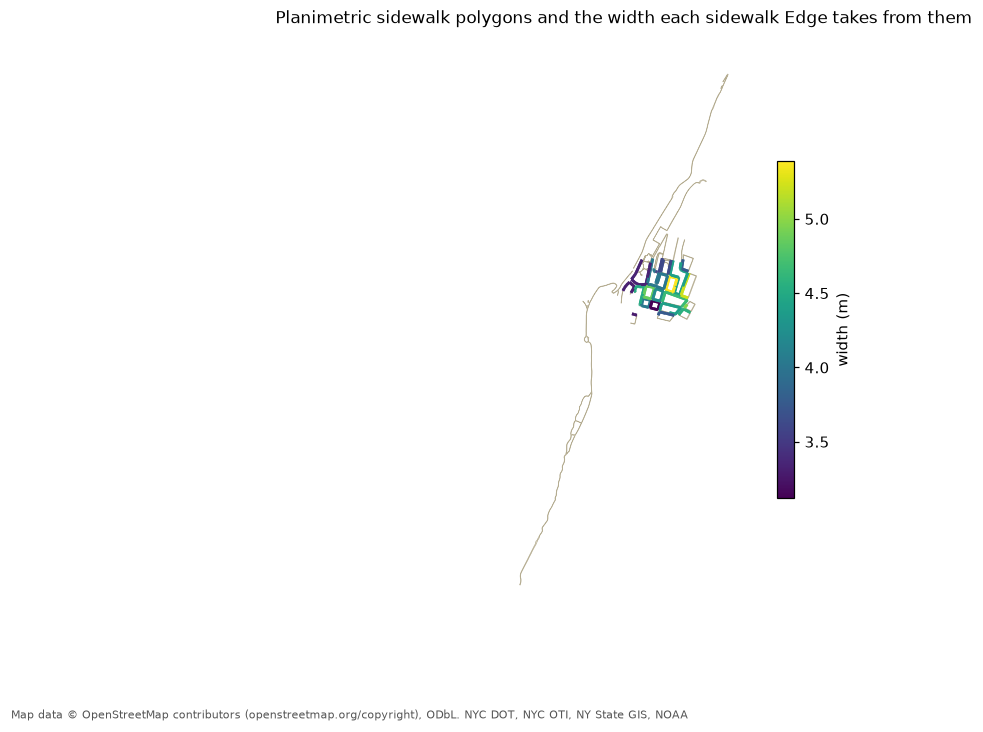

In [9]:
url = ("https://data.cityofnewyork.us/resource/52n9-sdep.geojson?$limit=5000&$where=" +
       quote(f"intersects(the_geom,'POLYGON(({AREA['west']} {AREA['south']},{AREA['east']} {AREA['south']},{AREA['east']} {AREA['north']},{AREA['west']} {AREA['north']},{AREA['west']} {AREA['south']}))')"))
polygons = read_open_data(url)
sidewalks = edges[edges["entity"] == "Sidewalk"]
recomputed = _join_widths_from_planimetric(sidewalks.drop(columns="width"), polygons)

fig, ax = plt.subplots(figsize=(9, 7)); credit(fig)
polygons.to_crs(UTM).plot(ax=ax, color="#e8e3d3", edgecolor="#b5ad92", linewidth=0.4)
recomputed.to_crs(UTM).plot(ax=ax, column="width", cmap="viridis", linewidth=1.8, legend=True,
                            legend_kwds={"label": "width (m)", "shrink": 0.6})
ax.set_title("Planimetric sidewalk polygons and the width each sidewalk Edge takes from them"); ax.set_axis_off()

In [10]:
compare = pd.DataFrame({"recomputed here": recomputed["width"], "in the release": sidewalks["width"]}).dropna()
print(f"{len(compare)} sidewalk Edges; recomputed and published widths agree on "
      f"{np.isclose(compare.iloc[:, 0], compare.iloc[:, 1], atol=0.01).mean():.0%} of them")
compare.describe().round(2)

494 sidewalk Edges; recomputed and published widths agree on 100% of them


,recomputed here,in the release
count,494.00,494.00
mean,4.15,4.15
std,0.60,0.60
min,3.12,3.12
25%,3.63,3.63
50%,4.22,4.22
75%,4.50,4.50
max,5.39,5.39


## Step 4: The LiDAR terrain model gives elevation and incline

The city's 2017 LiDAR survey has a bare-earth terrain model, served by NY State GIS. The pipeline downloads it in 2 m tiles, reads a height at each Node, and sets each Edge's `incline`, an estimate, to the rise over the run in its direction of travel. Before taking the difference it averages each Node's height with its neighbours' over Edges shorter than 5 m, so that survey noise on short Edges does not read as a slope. The recomputation below skips that averaging, so short Edges differ from the release.

  DEM [notebook]: 273×222 px (~2.0m res)...


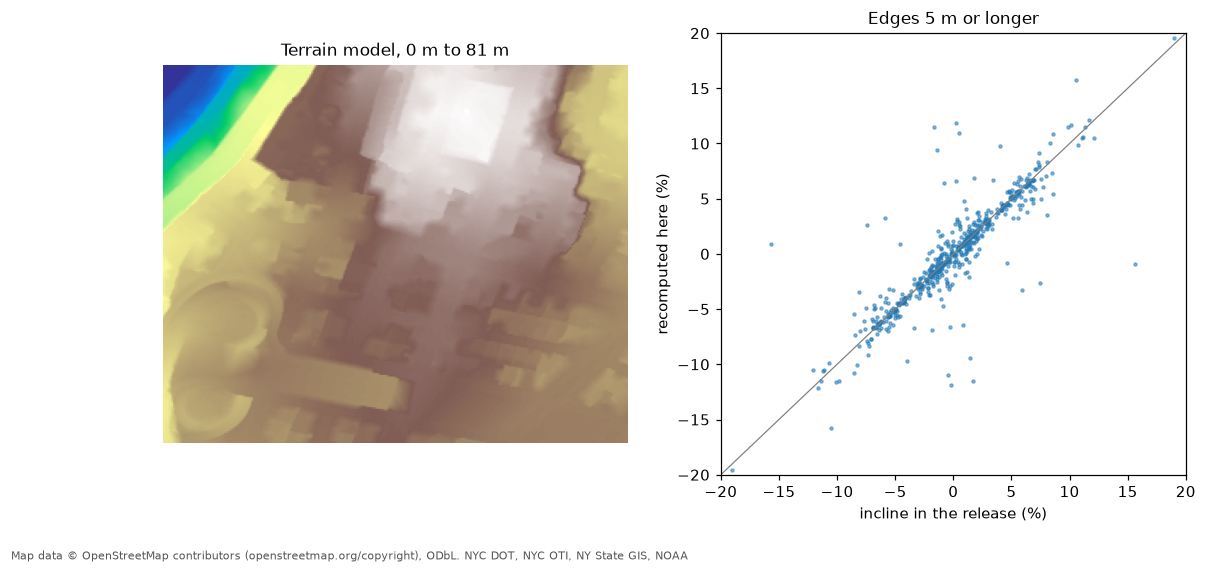

In [11]:
dem_path = Path(tempfile.mkdtemp()) / "dem.tif"
_fetch_dem_tile(AREA, "notebook", dem_path, resolution_m=2.0)
dem = rasterio.open(dem_path)

def heights(points):
    return np.array([v[0] for v in dem.sample([(p.x, p.y) for p in points])])

ped = edges[edges["entity"] != "Street"].copy()
starts = heights(ped.geometry.apply(lambda l: gpd.points_from_xy([l.coords[0][0]], [l.coords[0][1]])[0]))
ends = heights(ped.geometry.apply(lambda l: gpd.points_from_xy([l.coords[-1][0]], [l.coords[-1][1]])[0]))
ped["length_m"] = ped.to_crs(UTM).length
ped["incline_here"] = (ends - starts) / ped["length_m"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5)); credit(fig)
z = dem.read(1)
axes[0].imshow(z, cmap="terrain", extent=(dem.bounds.left, dem.bounds.right, dem.bounds.bottom, dem.bounds.top))
axes[0].set_title(f"Terrain model, {int(round(z.min()))} m to {int(round(z.max()))} m"); axes[0].set_axis_off()
long = ped[ped["length_m"] >= 5]
axes[1].scatter(long["incline"] * 100, long["incline_here"] * 100, s=4, alpha=0.5)
axes[1].plot([-20, 20], [-20, 20], color="grey", linewidth=0.8)
axes[1].set(xlim=(-20, 20), ylim=(-20, 20), xlabel="incline in the release (%)", ylabel="recomputed here (%)",
            title="Edges 5 m or longer");

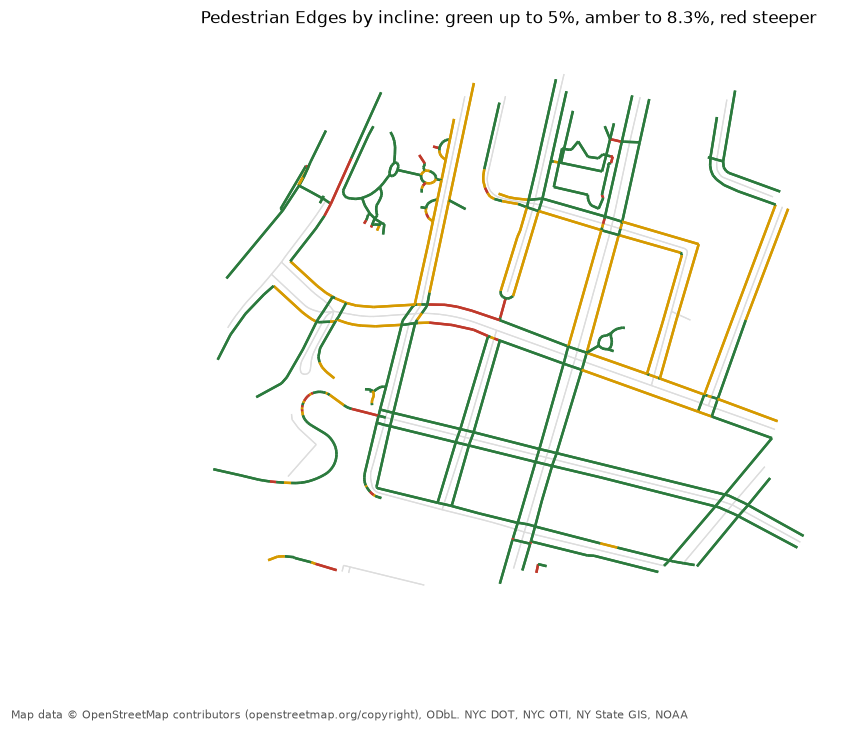

In [12]:
fig, ax = plt.subplots(figsize=(9, 7)); credit(fig)
edges[edges["entity"] == "Street"].to_crs(UTM).plot(ax=ax, color="#dddddd", linewidth=0.8)
steep = np.select([ped["incline"].abs() <= 0.05, ped["incline"].abs() <= 0.083], ["#2b7a3d", "#d69a00"], "#c0392b")
ped.to_crs(UTM).plot(ax=ax, color=steep, linewidth=1.6)
ax.set_title("Pedestrian Edges by incline: green up to 5%, amber to 8.3%, red steeper"); ax.set_axis_off()

## Step 5: On bridges, the point clouds give the deck

A bare-earth model describes what is under a bridge: the ground, or the water. For Nodes on bridges and elevated ways the pipeline reads the classified LiDAR point clouds (the 2017 city survey and, where that has no returns over open water, the 2014 USGS survey) and follows the walking surface from the ground at each end. Those Nodes carry `ext:elevation_source`. Reading the point clouds takes several minutes, so this cell compares the published deck heights on the Brooklyn Bridge with the terrain model under them.

  DEM [bridge]: 506×584 px (~2.0m res)...


,Nodes by height source
lidar_2017,33
lidar_2014,10


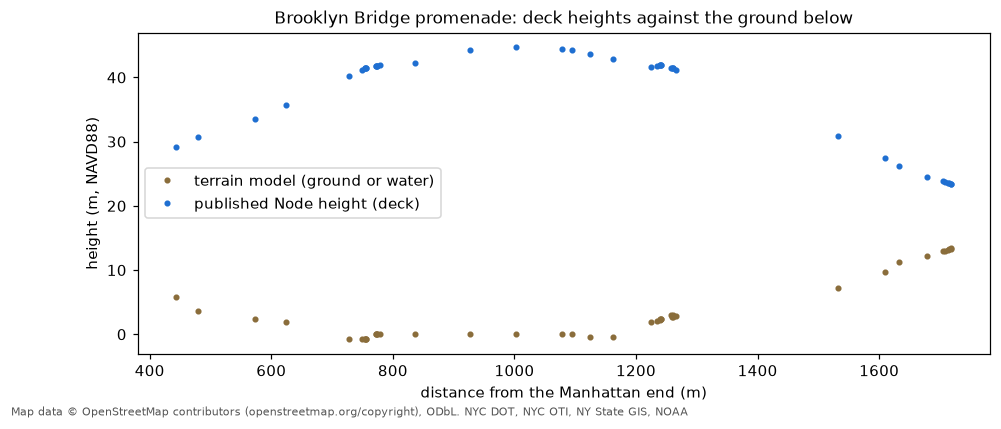

In [13]:
BRIDGE = dict(west=-74.0010, south=40.7010, east=-73.9890, north=40.7115)
b = gpd.read_file(RELEASE, bbox=(BRIDGE["west"], BRIDGE["south"], BRIDGE["east"], BRIDGE["north"]))
promenade = b[(b.geom_type == "LineString") & b["name"].fillna("").str.contains("Brooklyn Bridge")]
ids = set(promenade["_u_id"]) | set(promenade["_v_id"])
deck = b[(b.geom_type == "Point") & b["_id"].isin(ids) & b["ext:elevation_source"].notna()].copy()

dem_path = Path(tempfile.mkdtemp()) / "bridge.tif"
_fetch_dem_tile(BRIDGE, "bridge", dem_path, resolution_m=2.0)
dem = rasterio.open(dem_path)
deck["ground"] = heights(deck.geometry)
manhattan_end = gpd.GeoSeries(gpd.points_from_xy([-74.0045], [40.7123]), crs=4326).to_crs(UTM).iloc[0]
deck["distance"] = deck.to_crs(UTM).distance(manhattan_end)
deck = deck.sort_values("distance")

fig, ax = plt.subplots(figsize=(10, 4)); credit(fig)
ax.plot(deck["distance"], deck["ground"], ".", color="#8a6d3b", label="terrain model (ground or water)")
ax.plot(deck["distance"], deck["ext:elevation_m"], ".", color="#1f6fd1", label="published Node height (deck)")
ax.set(xlabel="distance from the Manhattan end (m)", ylabel="height (m, NAVD88)",
       title="Brooklyn Bridge promenade: deck heights against the ground below")
ax.legend(); deck["ext:elevation_source"].value_counts().rename("Nodes by height source").rename_axis(None).to_frame()

## Step 6: Assembly into a routable graph

Because every Edge names its Nodes, the graph needs no spatial matching. Two rules then make the wheelchair profile:

- A Crossing counts as ramped when a surveyed ramp lies within 5 m of each of its ends (`crossings_with_ramps`).
- The cost function refuses Steps, Street Edges, Crossings without ramps, and inclines over 8.3% up or 10% down (`unweaver-project/cost-wheelchair.py`).

Both are this project's rules, adapted from the example wheelchair profile of [Unweaver](https://github.com/nbolten/unweaver) by Nick Bolten (Apache License 2.0), the routing engine behind AccessMap. Following the OpenSidewalks approach, the data stores measured and estimated values, and a routing application chooses the rules.

In [14]:
features = json.loads(g.to_json(default=str))["features"]
node_xy = {r["_id"]: (r.geometry.x, r.geometry.y) for _, r in nodes.iterrows()}
endpoints = set(edges["_u_id"]) | set(edges["_v_id"])
curb_ids = [n for n in nodes.loc[nodes["entity"] == "Curb Ramp", "_id"] if n in endpoints]
ramped = osw_to_unweaver.crossings_with_ramps(features, curb_ids, node_xy, reach_m=5.0)

edges["length"] = edges.to_crs(UTM).length
G = nx.DiGraph()
for _, e in edges.iterrows():
    d = {"subclass": {"Steps": "steps", "Street": "street"}.get(e["entity"], e["footway"] or "footway"),
         "footway": e["footway"], "curbramps": e["_id"] in ramped,
         "incline": None if pd.isna(e["incline"]) else e["incline"], "length": e["length"], "geometry": e.geometry}
    if not G.has_edge(e["_u_id"], e["_v_id"]) or G[e["_u_id"]][e["_v_id"]]["length"] > d["length"]:
        G.add_edge(e["_u_id"], e["_v_id"], **d)

wheelchair = cost_wheelchair.cost_fun_generator(G)
def walking(u, v, d):
    return None if d["subclass"] == "street" else d["length"]
print(f"{G.number_of_nodes():,} Nodes, {G.number_of_edges():,} directed Edges, {len(ramped)} Crossing Edges ramped at both ends")

[crossings] 196 edges in 48 crossings; 196 edges on a crossing with a ramp at each end
809 Nodes, 1,816 directed Edges, 196 Crossing Edges ramped at both ends


A trip across the hill, from Fort Washington Avenue to Wadsworth Avenue. The walking profile takes the stairs. The wheelchair profile goes round.

walking: 538 m


wheelchair: 815 m


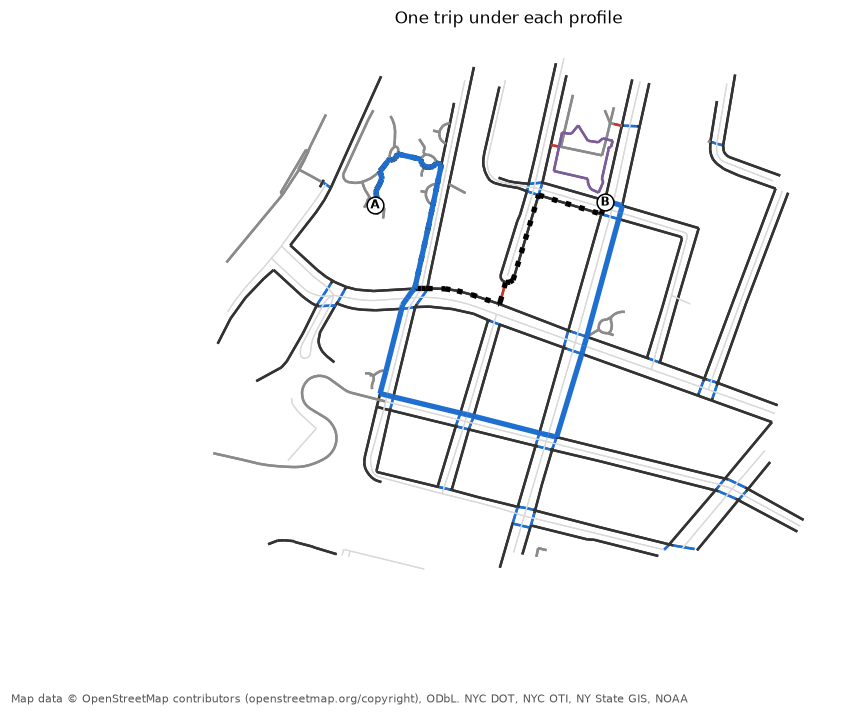

In [15]:
ORIGIN, DESTINATION = (-73.9407, 40.8522), (-73.9379, 40.8522)

def nearest(lon, lat):
    pts = nodes[nodes["_id"].isin(G.nodes)].to_crs(UTM)
    here = gpd.GeoSeries(gpd.points_from_xy([lon], [lat]), crs=4326).to_crs(UTM).iloc[0]
    return pts.loc[pts.distance(here).idxmin(), "_id"]

origin, destination = nearest(*ORIGIN), nearest(*DESTINATION)
routes = {}
for name, weight in [("walking", walking), ("wheelchair", wheelchair)]:
    try:
        path = nx.shortest_path(G, origin, destination, weight=weight)
        routes[name] = gpd.GeoSeries([G[a][b]["geometry"] for a, b in zip(path, path[1:])], crs=4326)
    except nx.NetworkXNoPath:
        routes[name] = None

fig, ax = plt.subplots(figsize=(9, 7)); credit(fig)
base_map(ax, "One trip under each profile")
for name, colour, style in [("walking", "black", ":"), ("wheelchair", "#1f6fd1", "-")]:
    if routes[name] is not None:
        routes[name].to_crs(UTM).plot(ax=ax, color=colour, linewidth=3.5, linestyle=style)
        print(f"{name}: {routes[name].to_crs(UTM).length.sum():.0f} m")
    else:
        print(f"{name}: no route")
ends = gpd.GeoSeries(gpd.points_from_xy([ORIGIN[0], DESTINATION[0]], [ORIGIN[1], DESTINATION[1]]), crs=4326).to_crs(UTM)
ax.scatter(ends.x, ends.y, s=120, color="white", edgecolor="black", zorder=5)
for label, p in zip("AB", ends):
    ax.annotate(label, (p.x, p.y), ha="center", va="center", fontsize=8, weight="bold", zorder=6)

## Step 7: Validation

The release is checked with the schema validator that the Taskar Center for Accessible Technology publishes, [`python-osw-validation`](https://pypi.org/project/python-osw-validation/) 0.5.0, which returns zero errors over all 4,068,058 features. The validator checks form, not whether the data matches the street. The checks it does not make (elevation, deck heights, connectivity by borough, ramps against the survey, widths) are in `validators/post_build_checks.py`, with results in `validators/QUALITY_REPORT.md`.

## What this notebook does not show

- Nothing here was checked on the ground. A surveyed ramp from 2018 may since have been rebuilt, blocked or removed.
- Incline comes from an airborne survey. A curb ramp a metre long is below what it can resolve.
- Where OpenStreetMap has no separately mapped sidewalk, the dataset has none.
- The 5 m ramp rule was checked on 200 crossings over aerial imagery by language-model raters (Anthropic Claude models, exact versions not recorded), not by people.

The full list, with the evidence for each claim, is in [`evaluation/README.md`](https://github.com/msradam/opensidewalks-nyc/blob/main/evaluation/README.md).

## Disclaimer

OpenSidewalks NYC is an experimental dataset. Nothing in it has been checked on the ground. Do not use it to tell anyone that a route is accessible.

The curb ramp survey shows that a ramp was there when it was captured, mostly in 2018, not that it is usable today. Incline and width are estimates.

OpenSidewalks NYC is an independent project by Adam Munawar Rahman. It is not made or endorsed by the Taskar Center for Accessible Technology, OpenSidewalks or TDEI, nor by NYC DOT or the City of New York.

Language models drafted most of the code and documentation and did the imagery ratings. [How This Was Made](https://github.com/msradam/opensidewalks-nyc#how-this-was-made) says how they were used.